In [7]:
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from ultralytics import YOLO
import pandas as pd

In [9]:
DATASET_ROOT = Path("/home/lewagon/code/TheTrueJACKSONIAN/ppe_detection_2305/data/Construction-PPE-3")

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_LABELS = DATASET_ROOT / "train" / "labels"

VALID_IMAGES = DATASET_ROOT / "valid" / "images"
VALID_LABELS = DATASET_ROOT / "valid" / "labels"

TEST_IMAGES = DATASET_ROOT / "test" / "images"
TEST_LABELS = DATASET_ROOT / "test" / "labels"

YAML_PATH = DATASET_ROOT / "data.yaml"

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"
}

In [3]:
CLASS_NAMES = ['Gloves', 'Helmet', 'Human', 'Safety Boot', 'Safety Vest', 'boots', 'glasses', 'gloves', 'hat', 'helmet', 'no boot', 'no boots', 'no gloves', 'no hat', 'no vest', 'vest']

In [5]:
SPLITS = ["train", "valid", "test"]

In [10]:
def load_yolo_annotations(dataset_root, splits):
    """
    Read YOLO-format label files.

    Expected format:
    class_id x_center y_center width height
    """

    annotation_records = []
    dataset_summary = []

    for split in splits:
        images_directory = dataset_root / split / "images"
        labels_directory = dataset_root / split / "labels"

        if not images_directory.exists():
            print(f"Images directory not found: {images_directory}")
            continue

        if not labels_directory.exists():
            print(f"Labels directory not found: {labels_directory}")
            continue

        image_files = [
            path for path in images_directory.iterdir()
            if path.suffix.lower() in IMAGE_EXTENSIONS
        ]

        label_files = list(labels_directory.glob("*.txt"))

        empty_label_files = 0
        invalid_label_rows = 0
        images_without_labels = 0

        for image_path in image_files:
            label_path = labels_directory / f"{image_path.stem}.txt"

            if not label_path.exists():
                images_without_labels += 1
                continue

            lines = [
                line.strip()
                for line in label_path.read_text(encoding="utf-8").splitlines()
                if line.strip()
            ]

            if not lines:
                empty_label_files += 1
                continue

            for line_number, line in enumerate(lines, start=1):
                values = line.split()

                if len(values) != 5:
                    invalid_label_rows += 1
                    print(
                        f"Invalid row: {label_path}, "
                        f"line {line_number}: {line}"
                    )
                    continue

                try:
                    class_id = int(float(values[0]))
                    x_center, y_center, width, height = map(float, values[1:])

                    annotation_records.append({
                        "split": split,
                        "image_name": image_path.name,
                        "label_name": label_path.name,
                        "class_id": class_id,
                        "x_center": x_center,
                        "y_center": y_center,
                        "width": width,
                        "height": height
                    })

                except ValueError:
                    invalid_label_rows += 1
                    print(
                        f"Non-numeric row: {label_path}, "
                        f"line {line_number}: {line}"
                    )

        dataset_summary.append({
            "split": split,
            "number_of_images": len(image_files),
            "number_of_label_files": len(label_files),
            "number_of_boxes": sum(
                record["split"] == split
                for record in annotation_records
            ),
            "empty_label_files": empty_label_files,
            "images_without_labels": images_without_labels,
            "invalid_label_rows": invalid_label_rows
        })

    annotations_df = pd.DataFrame(annotation_records)
    dataset_summary_df = pd.DataFrame(dataset_summary)

    return annotations_df, dataset_summary_df


annotations_df, dataset_summary_df = load_yolo_annotations(
    DATASET_ROOT,
    SPLITS
)

dataset_summary_df

,split,number_of_images,number_of_label_files,number_of_boxes,empty_label_files,images_without_labels,invalid_label_rows
0,train,7602,7602,38268,0,0,0
1,valid,851,851,4601,0,0,0
2,test,392,392,1995,0,0,0


In [13]:
annotations_df.head()

,split,image_name,label_name,class_id,x_center,y_center,width,height
0,train,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,2,0.499219,0.425000,0.342187,0.568750
1,train,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,4,0.497656,0.357812,0.232813,0.200000
2,train,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,3,0.428906,0.642188,0.089063,0.115625
3,train,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,3,0.571875,0.641406,0.090625,0.117188
4,train,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,Video1_0_jpg.rf.71bd91cec924a55c0ffc618fad1b90...,0,0.377344,0.482031,0.064062,0.048438


In [11]:
class_distribution = (
    annotations_df
    .groupby("class_id")
    .size()
    .reset_index(name="number_of_boxes")
    .sort_values("number_of_boxes", ascending=False)
)

class_distribution["percentage"] = (
    class_distribution["number_of_boxes"]
    / class_distribution["number_of_boxes"].sum()
    * 100
).round(2)

class_distribution

,class_id,number_of_boxes,percentage
3,3,9325,20.79
4,4,7384,16.46
2,2,5775,12.87
1,1,5482,12.22
0,0,3452,7.69
15,15,3073,6.85
5,5,2329,5.19
7,7,1893,4.22
8,8,1669,3.72
14,14,1374,3.06


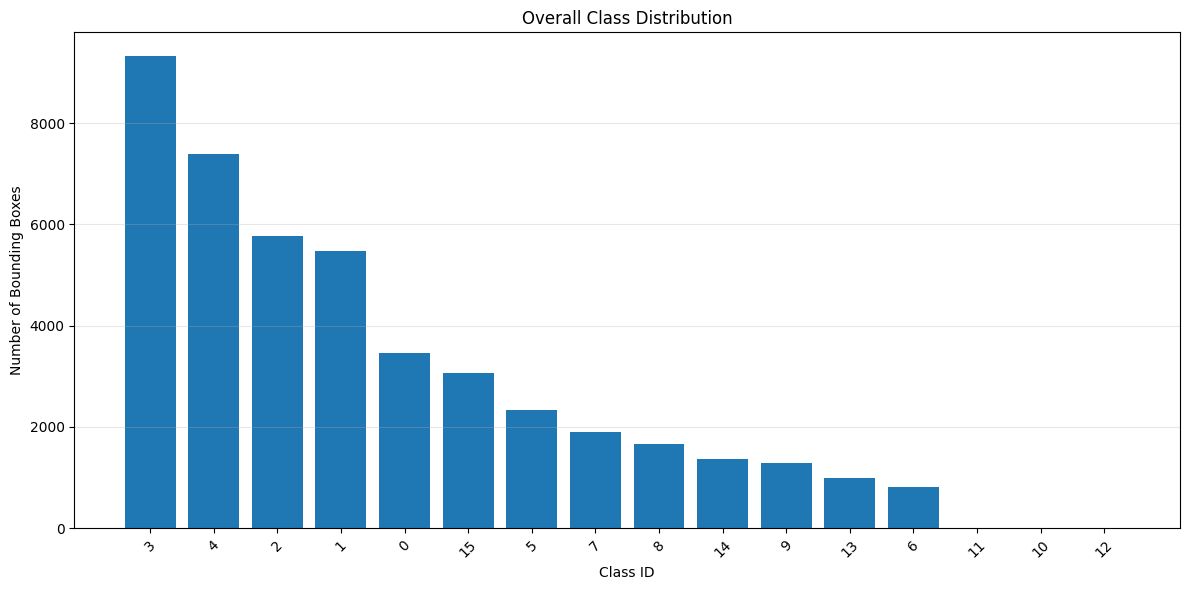

In [12]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_distribution["class_id"].astype(str),
    class_distribution["number_of_boxes"]
)

plt.title("Overall Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Bounding Boxes")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
CLASS_ID_TO_NAME = {
    class_id: class_name
    for class_id, class_name in enumerate(CLASS_NAMES)
}

In [15]:
class_distribution = (
    annotations_df
    .groupby("class_id")
    .size()
    .reset_index(name="number_of_boxes")
)

# Add class names
class_distribution["class_name"] = (
    class_distribution["class_id"]
    .map(CLASS_ID_TO_NAME)
)

# Calculate percentage
class_distribution["percentage"] = (
    class_distribution["number_of_boxes"]
    / class_distribution["number_of_boxes"].sum()
    * 100
).round(2)

# Sort from highest to lowest
class_distribution = class_distribution.sort_values(
    "number_of_boxes",
    ascending=True
)

class_distribution

,class_id,number_of_boxes,class_name,percentage
12,12,1,no gloves,0.00
10,10,1,no boot,0.00
11,11,8,no boots,0.02
6,6,810,glasses,1.81
13,13,994,no hat,2.22
9,9,1294,helmet,2.88
14,14,1374,no vest,3.06
8,8,1669,hat,3.72
7,7,1893,gloves,4.22
5,5,2329,boots,5.19


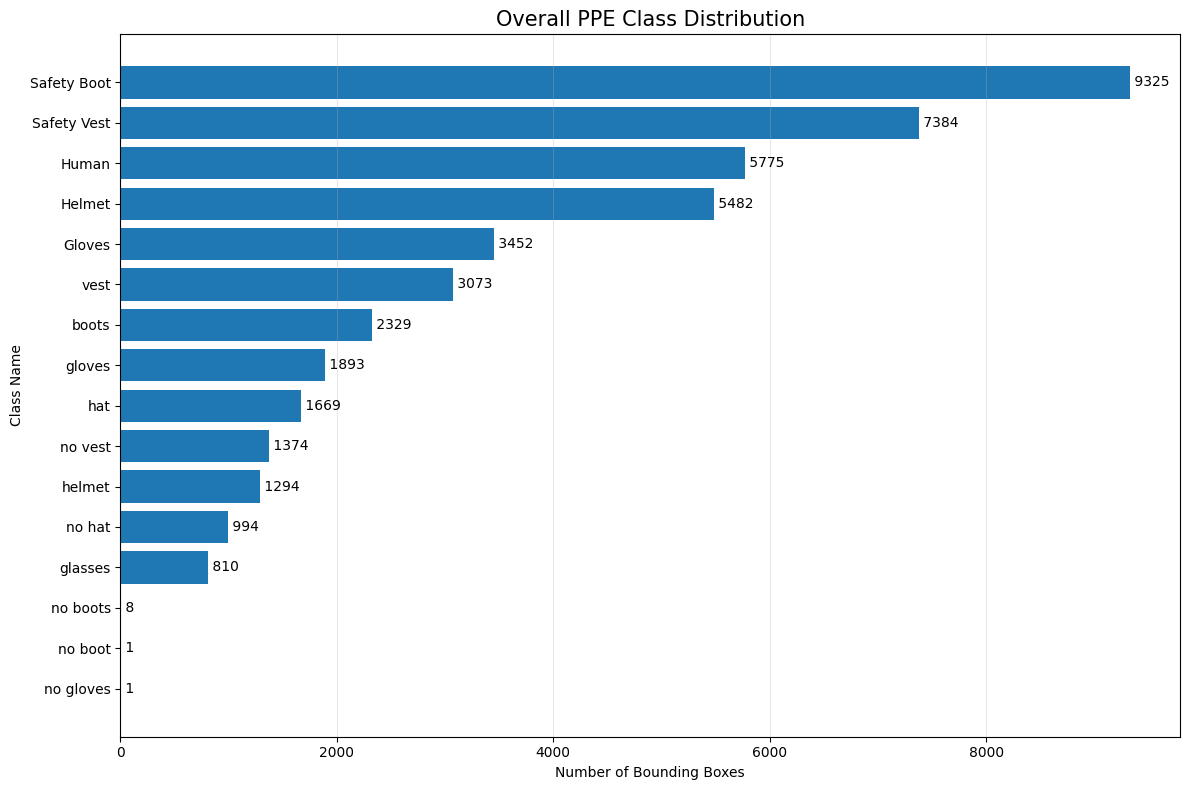

In [16]:
plt.figure(figsize=(12, 8))

bars = plt.barh(
    class_distribution["class_name"],
    class_distribution["number_of_boxes"]
)

plt.title("Overall PPE Class Distribution", fontsize=15)
plt.xlabel("Number of Bounding Boxes")
plt.ylabel("Class Name")
plt.grid(axis="x", alpha=0.3)

# Add count labels to the bars
for bar, count in zip(
    bars,
    class_distribution["number_of_boxes"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [17]:
FINAL_CLASS_NAMES = ["Safety Boot","Safety Vest","Human","Helmet","Gloves","vest","boots","gloves","hat","no vest","helmet","no hat","glasses","no boots","no boot","no gloves"]